# Smart Microscopy v3.1 — Adaptive Target Acquisition

Acquire an overview scan at the source objective, segment cells, pick targets from the cell distribution, then re-acquire those targets at the target objective.

## Workflow

| Step | What it does | Before you run it |
|------|--------------|-------------------|
| 1. Initialization | Connect, validate, boot the engine | Connect LAS X |
| 2a. Define limits | Derive XY stage limits | Place boundary markers |
| 2b. Define positions | Read the scan-field tiles | Draw the scan field |
| 2c. Define focus map | Fit a z-wide focus surface | Place focus markers |
| 2d. Archive & strip | Save the configured workflow, then strip LAS X for good | — |
| 3. Acquire overview | Scan and segment every tile | — |
| 4. Target discovery | Pick targets from the distribution | — |
| 5. Target acquisition | Re-acquire targets at high magnification | — |
| 6. Finish | Write the summary, plot, shut down | — |

All workflow logic lives in `notebooks/workflow/`; this notebook is a thin wrapper. See `docs/TARGET_ACQUISITION_DESIGN.md` for the design.

## Configuration

Edit the cell below for your experiment, then run the steps in order.

`simulate=True` is a **simulator-only dry run**: every saved `.ome.tiff` from Step 3 and Step 5 has its pixels swapped for mock content (`mock_image_source` picks the source) under the original LAS X simulator's OME envelope, so the rest of the pipeline behaves identically to a real acquisition. A per-frame `SystemTypeName="SIMULATOR"` guard hard-aborts the run if any frame is not from the simulator — `simulate=True` cannot touch real-instrument data.

`visualize=False` skips the per-tile, per-target, and selection figures in Steps 3, 4, 5. Use it for large runs (e.g. well plates) where rendering and saving every frame becomes prohibitive; Step 2 plots always render.

**Before a real run:** set `simulate=False`, check each job's objective in LAS X, and set the z-galvo to 0.

In [1]:
from _workflow_bootstrap import Config, Path

cfg = Config(
    # Jobs (each has an objective configured in LAS X)
    acquisition_job="Overview",
    target_job="HiRes",
    af_job="AF Job",

    # Paths
    analysis_repo=Path(r"Z:\zmbstaff\10374\Protocols_Notes\thom\notes\repositories\smart-analysis"),
    experiment="v3-test",   # driver derives output_root as media_path/smart

    # Simulator dry run (LAS X simulator only). When True, every saved
    # .ome.tiff from Step 3 / Step 5 has its pixels overwritten with
    # mock content; the OME envelope, naming, layout, and analysis flow
    # are otherwise unchanged. The per-frame SystemTypeName=="SIMULATOR"
    # guard makes this unsafe to enable on real hardware -- the run
    # hard-aborts on the first non-simulator frame.
    simulate=True,
    mock_image_source="skimage_human_mitosis",
    # simulate=True,
    # mock_image_source="skimage_human_mitosis",

    # Per-tile / per-target / selection visualization for Steps 3, 4, 5.
    # Set False for large runs (e.g. well plates) where rendering and
    # saving every tile/target is prohibitive. Step 2 plots are always
    # rendered.
    visualize=True,
)

## Step 1 — Initialization

Connects to LAS X, validates hardware and calibration, derives objective slots, and boots the analysis engine.

**Before running:** connect LAS X.

In [2]:
from workflow import connect_lasx, preflight

client = connect_lasx()
ctx = preflight(cfg, client)


[job] 'Overview' selected (slot 0)
[step 1] preflight ok
  templates_dir : C:\Users\t.de\AppData\Roaming\Leica Microsystems\LAS X\MatrixScreener6\User_0\ScanningTemplates
  out_dir       : Z:\zmbstaff\10374\Temporary_Data\smart\v3-test_0789kh
  current_job   : Overview  (slot 0)
  target_job    : HiRes  (slot 0)
  source z-galvo: -0.000 um
  cellpose env  : present


## Step 2 — Setup overview

Configure the overview scan's spatial extent. Run 2a → 2b → 2c in order.

### Step 2a — Define limits

Derives XY stage limits from boundary markers (or uses the physical envelope if none are placed) and forces every job to z-wide.

**Before running:** place point markers at the sample corners in Navigator Expert, or skip to use the physical envelope.

[step 2a] Stage limits from 4 boundary marker(s) (envelope from stage.json):
  X: 28067 - 36120 um
  Y: 15017 - 24109 um
  z-wide: 0 - 25000 um (from stage.json)
[step 2a] Template stripped and z-wide enforced on every job.
[step 2a] Saved Z:\zmbstaff\10374\Temporary_Data\smart\v3-test_0789kh\initialization\logs\stage_envelope.png


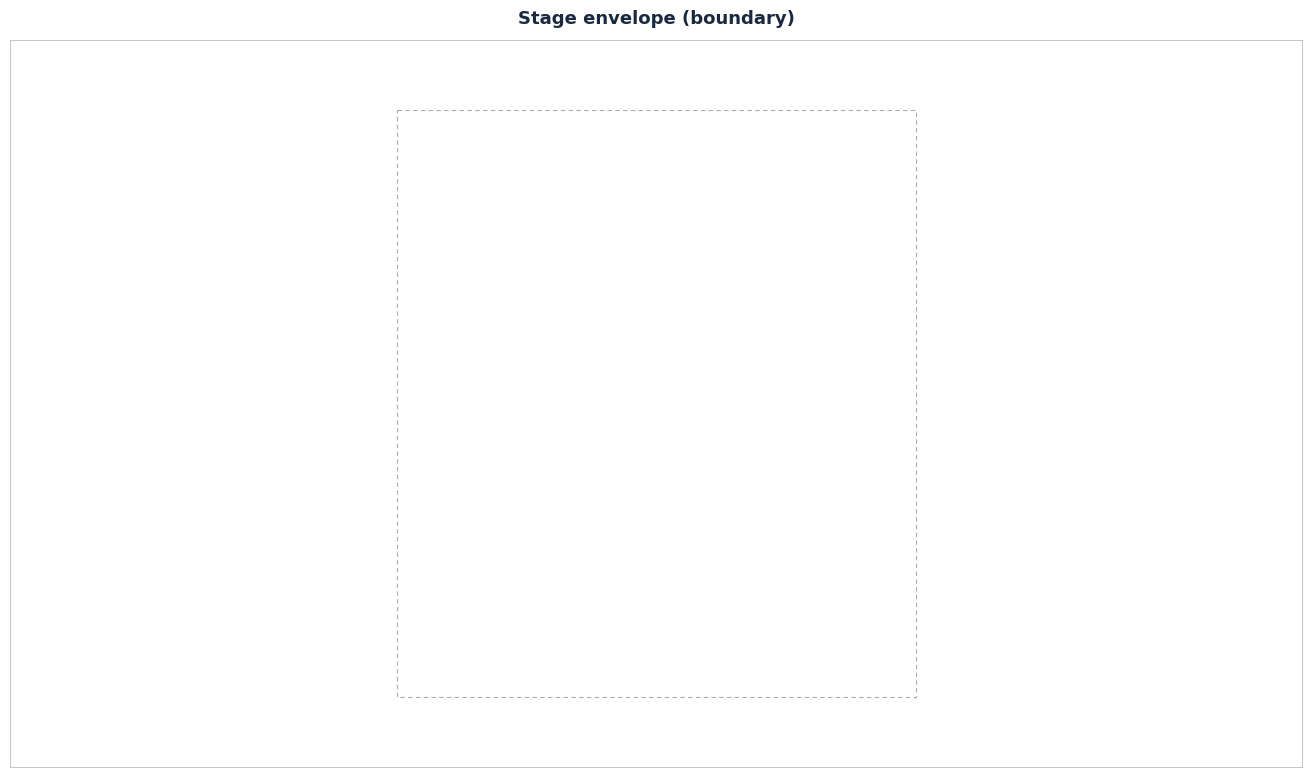

In [3]:
from workflow import prepare_template, plot_stage_envelope

prepare_template(ctx)
plot_stage_envelope(ctx)

### Step 2b — Define positions

Reads the scan field you drew — it defines which tiles the overview acquires.

**Before running:** draw the scan field in Navigator Expert.

[step 2b] Synthesized 2 tiles from geometries (tile size 1160.0 um)
[step 2b] Scan field: 1 group(s), 2 tile(s)
  Group 0: Overview  1x2  tile=1160.0 um
[step 2b] Saved Z:\zmbstaff\10374\Temporary_Data\smart\v3-test_0789kh\initialization\logs\overview_field.png


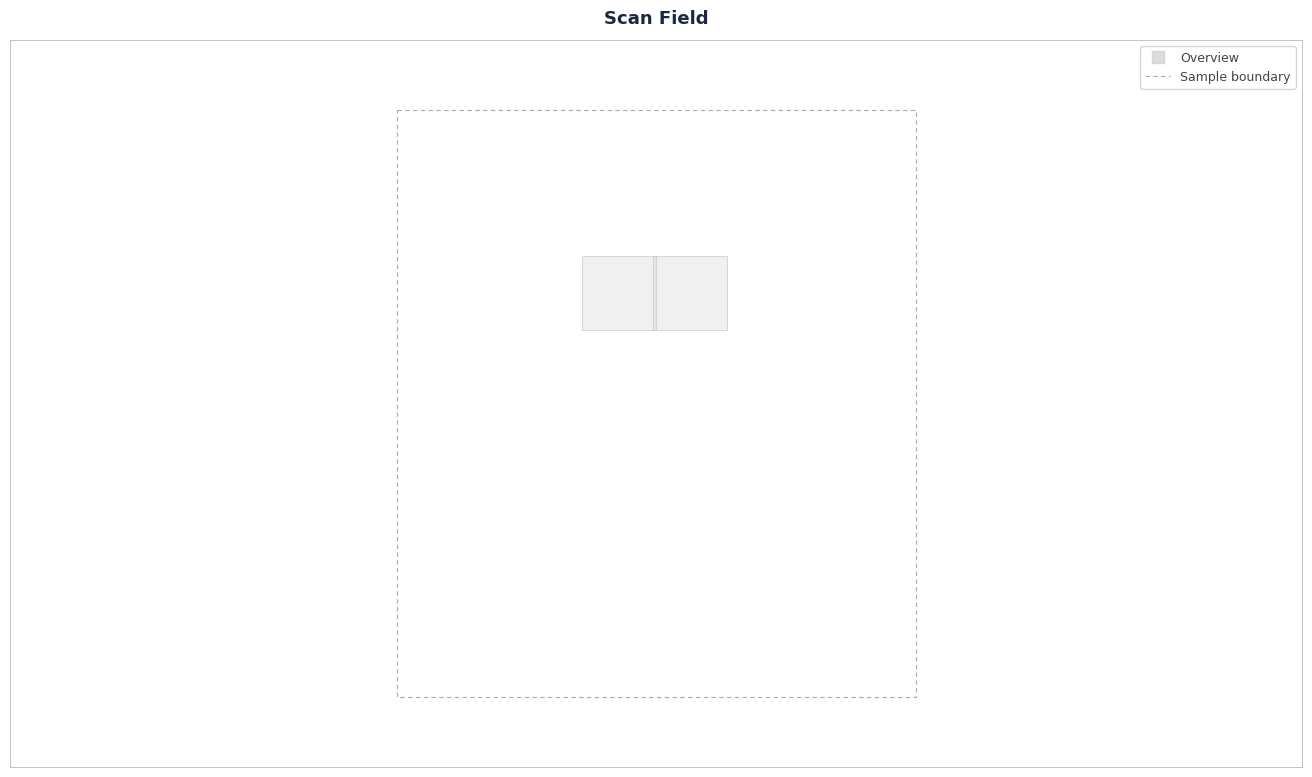

In [4]:
from workflow import read_scan_field, plot_scan_field

read_scan_field(ctx)
plot_scan_field(ctx)

### Step 2c — Define focus map

Runs autofocus at each focus marker and fits a z-wide surface across the scan field.

**Before running:** place focus markers on the scan field in Navigator Expert.

[step 2c] Focus positions (2):
  1. x=31721.3  y=17781.2 um
  2. x=32265.2  y=17875.0 um
[job] 'AF Job' selected (slot 0)

[1/2] x=31721  y=17781  z-wide=1000.00 um

[2/2] x=32265  y=17875

get_xy: attempt 1/3 receipt failed


  z-wide=1000.00 um

[step 2c] Focus model: constant (2 points)
  Z mean:       1000.00 um
[step 2c] Saved Z:\zmbstaff\10374\Temporary_Data\smart\v3-test_0789kh\initialization\logs\focus_map.png


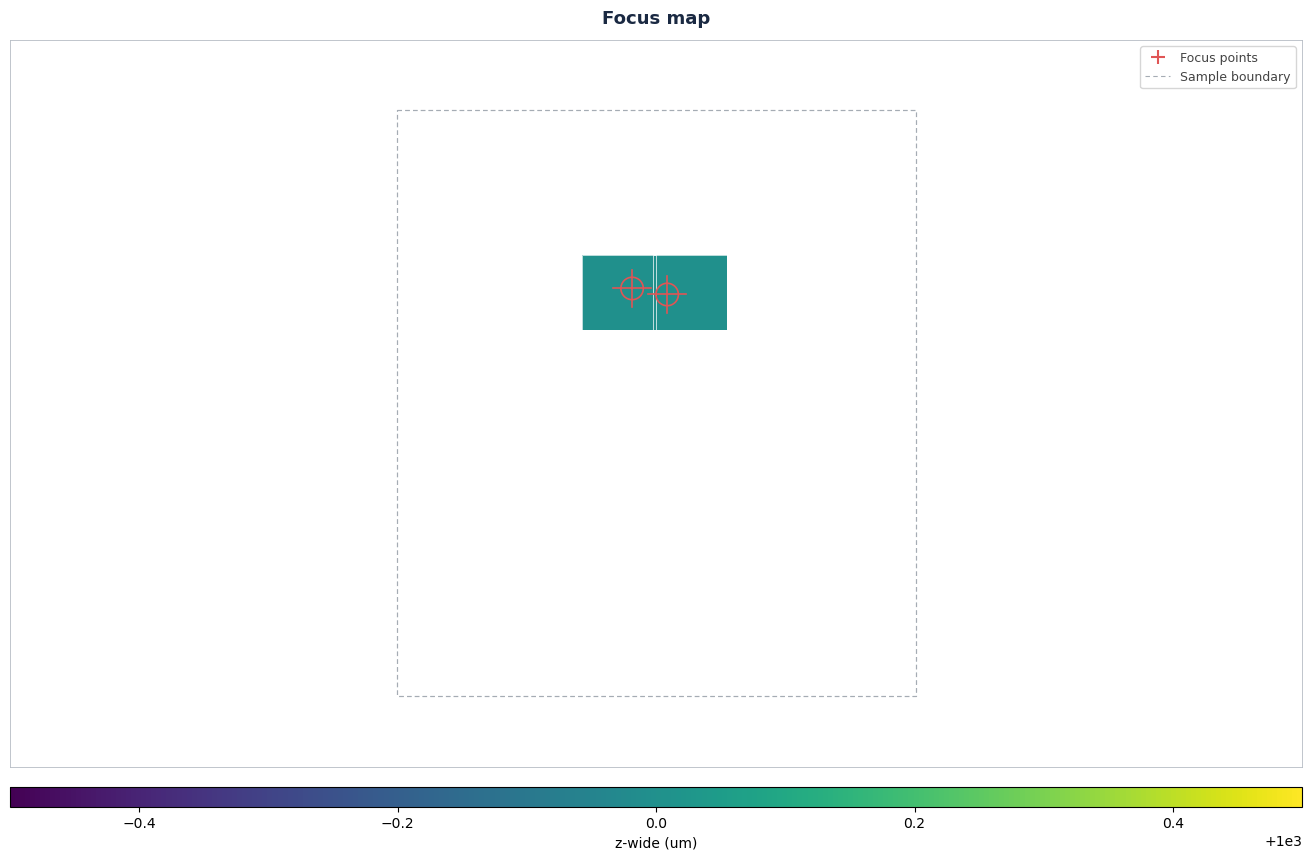

In [5]:
from workflow import build_focus_map

focus_map = build_focus_map(ctx)
focus_map.plot(ctx)

### Step 2d — Archive workflow and strip

Saves the configured workflow (xml, lrp, rgn) to the initialization metadata folder, then strips the scan field and markers from Navigator Expert for the rest of the run. From here on the template stays stripped — Step 3 and Step 5 no longer touch the template.

In [6]:
from workflow import archive_and_strip

archive_and_strip(ctx)

[step 2d] Archived 3 workflow file(s) to Z:\zmbstaff\10374\Temporary_Data\smart\v3-test_0789kh\initialization\data\metadata: {ScanningTemplate}_PythonInspect.xml, {ScanningTemplate}_PythonInspect.lrp, {ScanningTemplate}_PythonInspect.rgn
[step 2d] Template stripped. Scan field and markers will not be restored.


## Step 3 — Acquire overview

Acquires every tile in snake order, segments each with cellpose, and writes the per-tile results to disk. Each tile is shown inline when `cfg.visualize=True`.

[job] 'Overview' selected (slot 0)
[step 3] 2 tiles in snake order
[1/2] Group 0, Position 0  x=31517 y=17847 z=1000.00  ok
[2/2] Group 0, Position 1  x=32619 y=17847 z=1000.00  ok


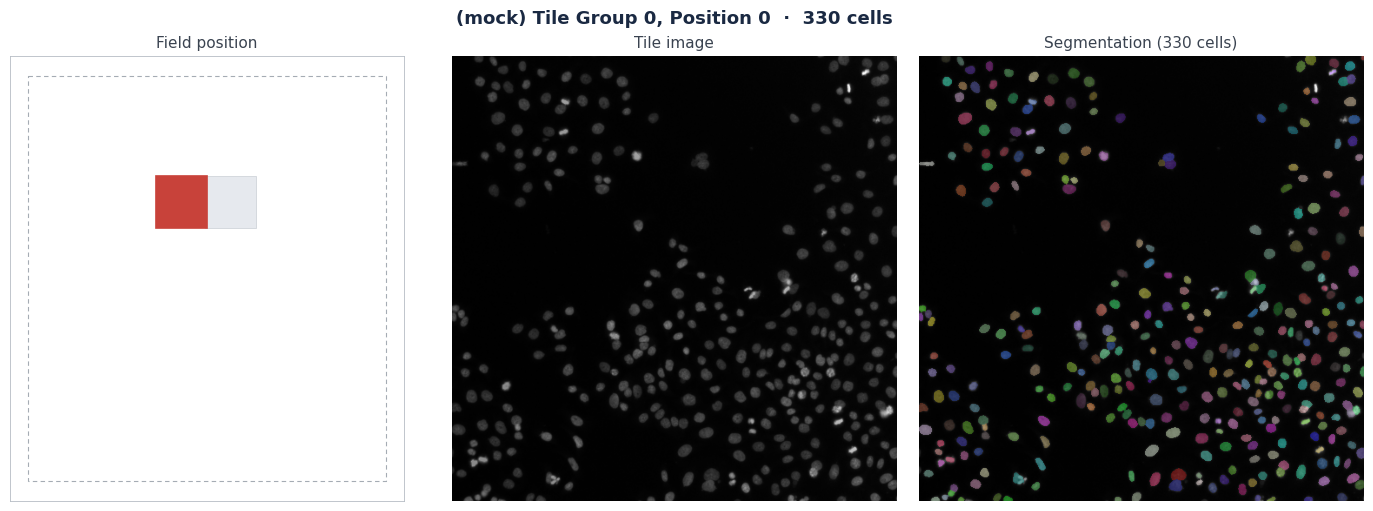

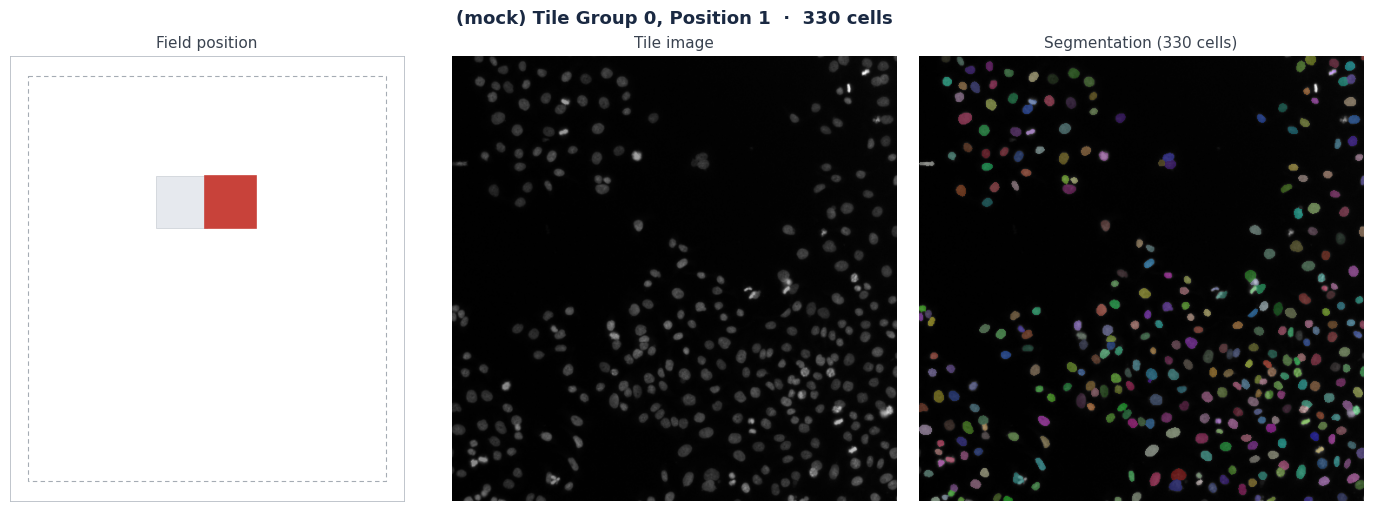


[step 3] Drain complete: 2 result(s), 0 engine failure(s), 0 tile acquire failure(s), 0 npz save failure(s). 2 tile(s) persisted.


In [7]:
from workflow import run_overview

overview = run_overview(
    ctx, focus_map,
    live_display=cfg.visualize,
    save_png=cfg.visualize,
)

## Step 4 — Target discovery

Loads the overview, applies area / intensity thresholds, and picks target cells — shown as a scatter plus example crops.

Re-run with different `area_threshold`, `intensity_threshold`, `n_per_tile`, or `border_margin_px` to iterate without re-acquiring the overview.

[step 4] mode=threshold, total=660 (330 near-border excluded), qualifying=54, selected_pre_dedup=8, final=8 (area_threshold=87.0 auto, intensity_threshold=63.3 auto, border_margin_px=64)


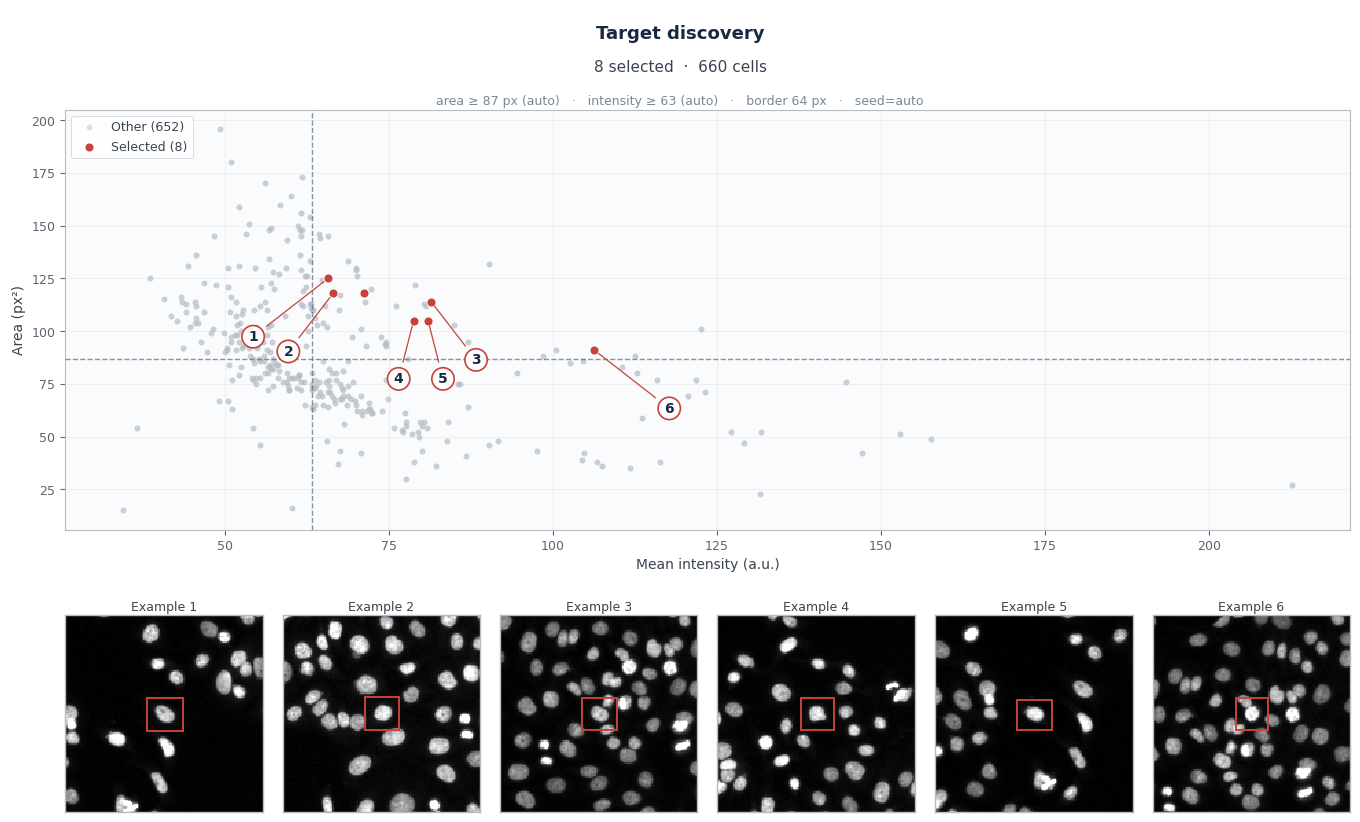

In [8]:
from workflow.selection import select_targets, load_overview_result
from workflow.visualize import display_selection

_analysis_dir = ctx.run.layout.analysis_dir("overview-scan")
overview = load_overview_result(_analysis_dir)   # kernel-restart safe

# Auto thresholds by default; uncomment to override. border_margin_px=64
# excludes cells whose bbox is within 64 px of any tile edge -- they have
# truncated stats and produce unreliable picks. Set to 0 to disable.
picks, selection = select_targets(
    overview,
    ctx.limits_context(),
    n_per_tile=4,
    border_margin_px=64,
    # area_threshold=200,
    # intensity_threshold=100,
    # seed=42,
)
if cfg.visualize:
    display_selection(
        selection, _analysis_dir,
        logs_dir=ctx.run.layout.logs_dir("overview-scan"),
    )

## Step 5 — Target acquisition

Switches to the target job and re-acquires each picked cell at high magnification; a failed pick does not stop the rest.

[job] 'HiRes' selected (slot 0)
[step 5] 8 picks to acquire at slot 0
[1/8] Group 0, Position 0, label 249  src=(31146, 17591)  ok  tz=1000.0


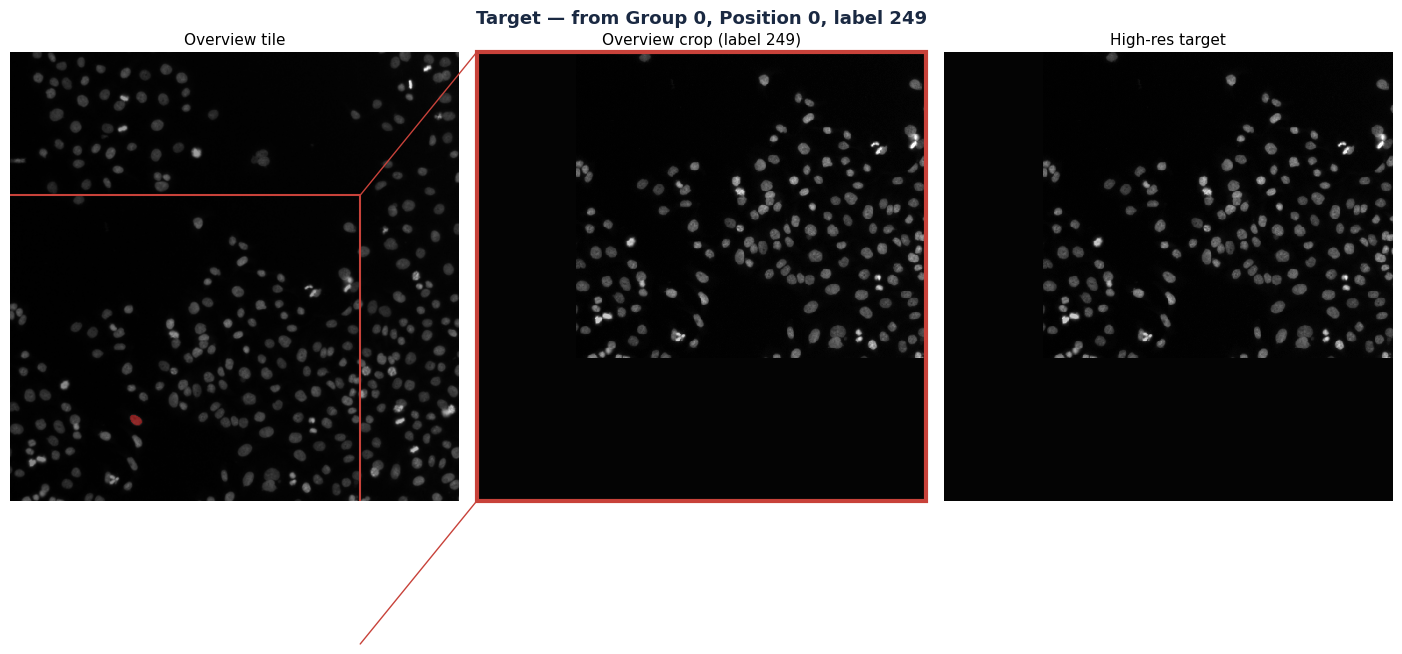

[2/8] Group 0, Position 0, label 244  src=(31155, 17911)  ok  tz=1000.0


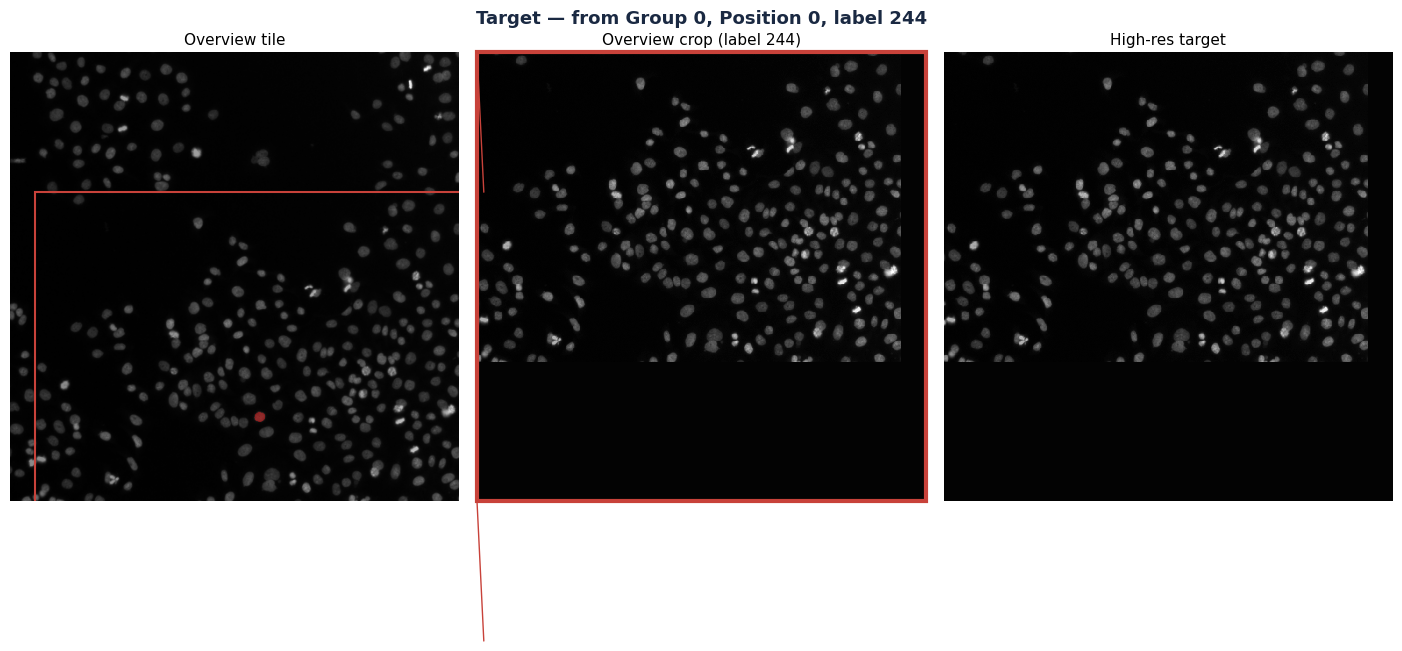

[3/8] Group 0, Position 0, label 228  src=(31197, 18137)  ok  tz=1000.0


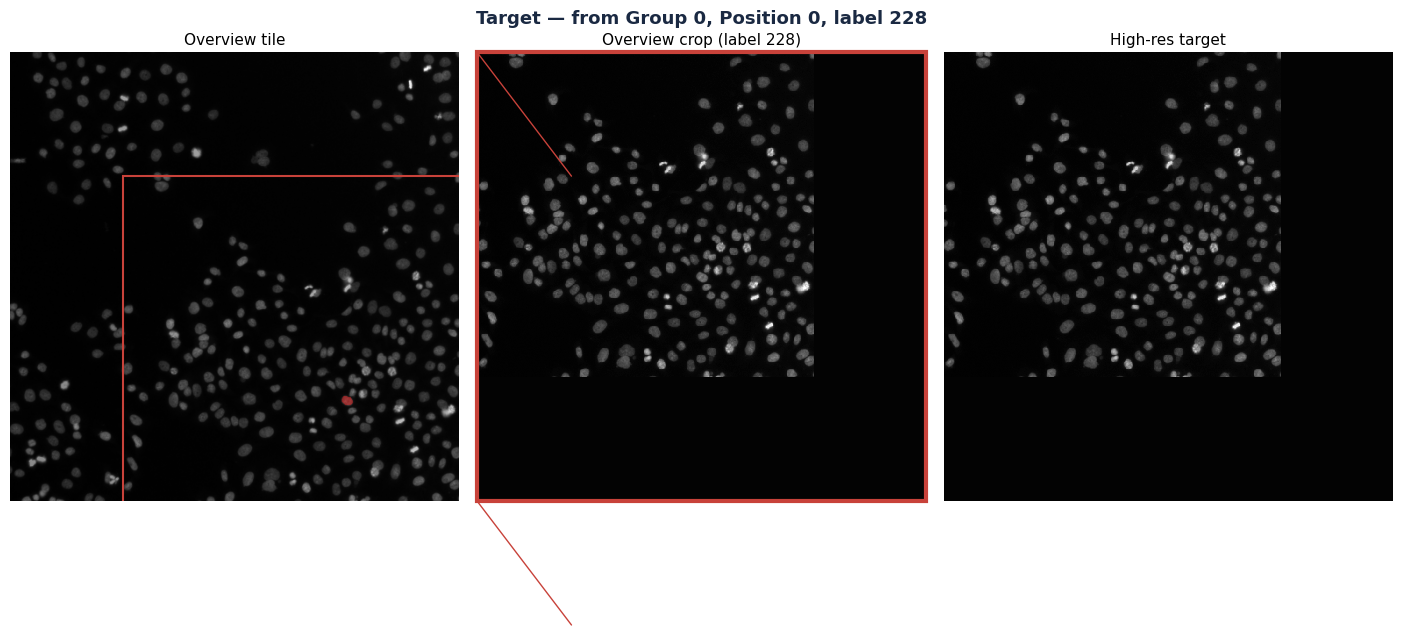

[4/8] Group 0, Position 0, label 216  src=(31221, 18057)  ok  tz=1000.0


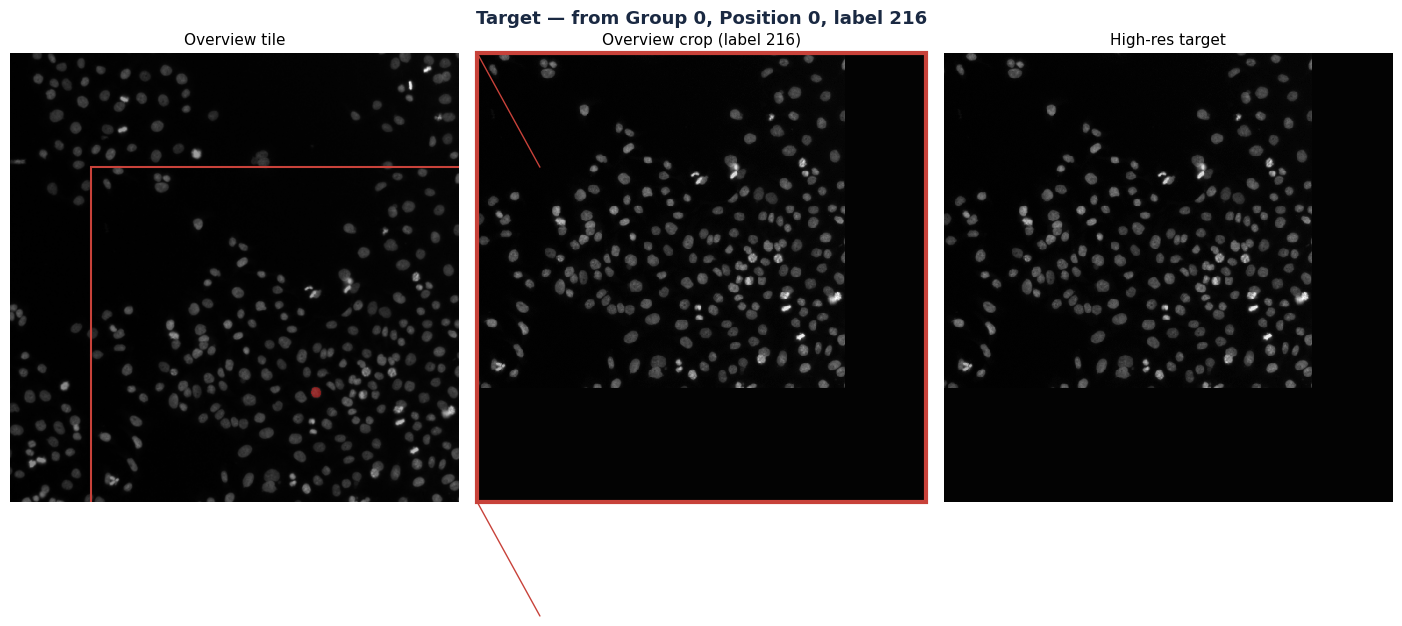

[5/8] Group 0, Position 1, label 269  src=(32208, 17512)  ok  tz=1000.0


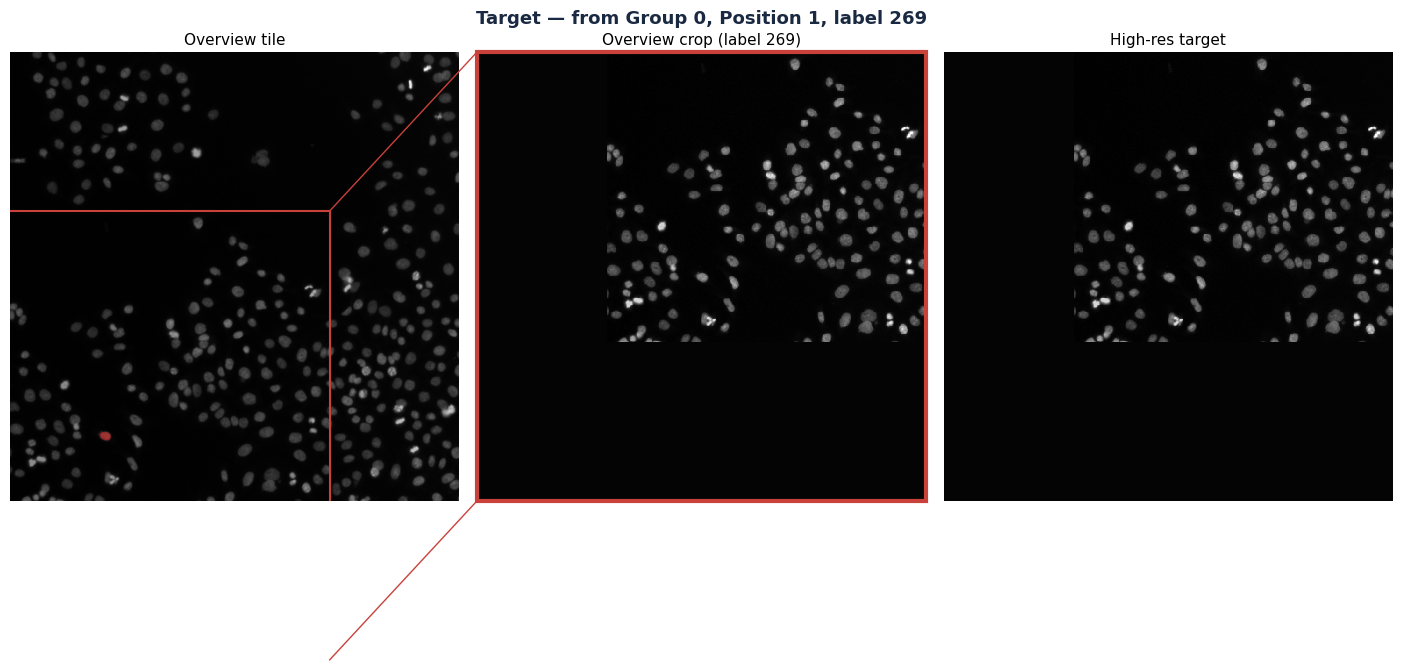

[6/8] Group 0, Position 1, label 216  src=(32323, 18057)  ok  tz=1000.0


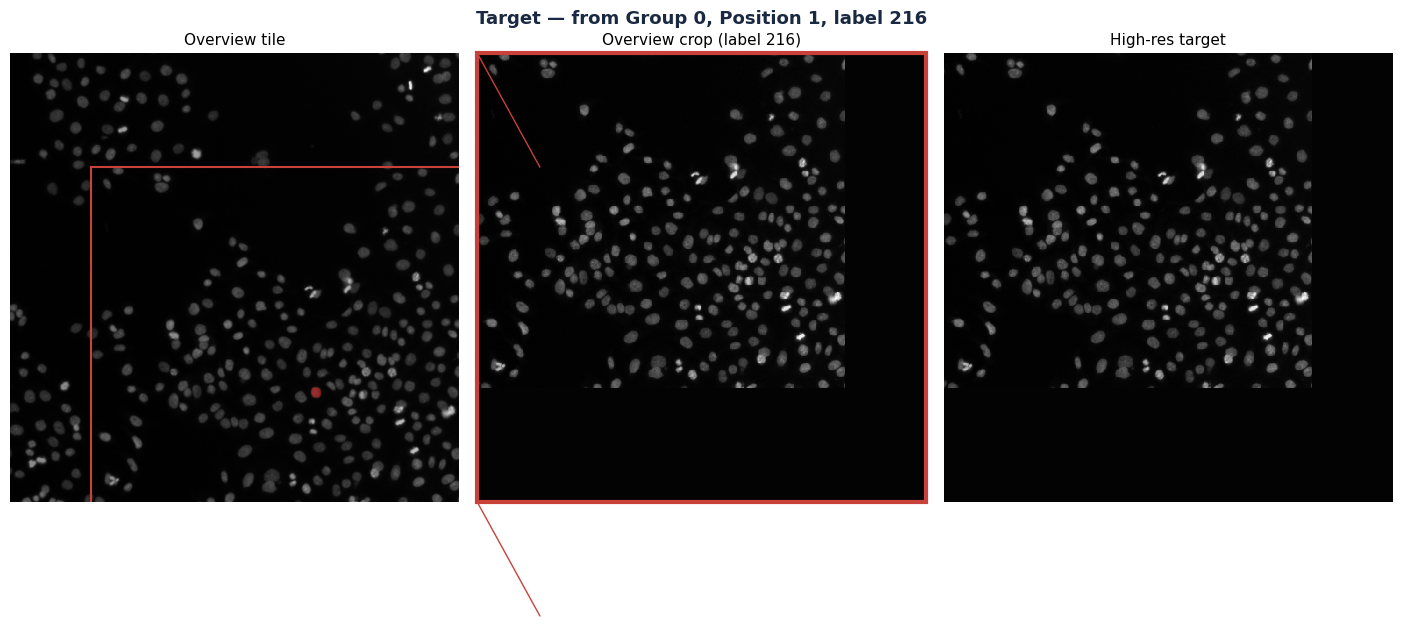

[7/8] Group 0, Position 1, label 188  src=(32376, 18186)  ok  tz=1000.0


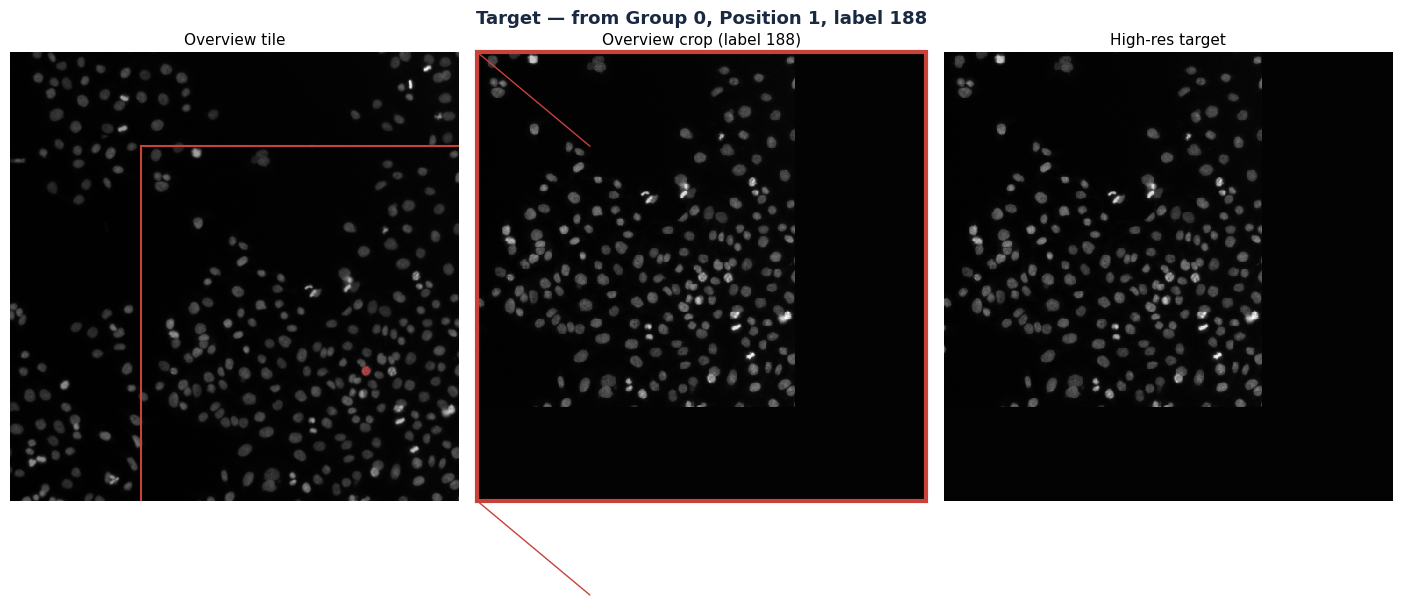

[8/8] Group 0, Position 1, label 112  src=(32546, 17913)  ok  tz=1000.0


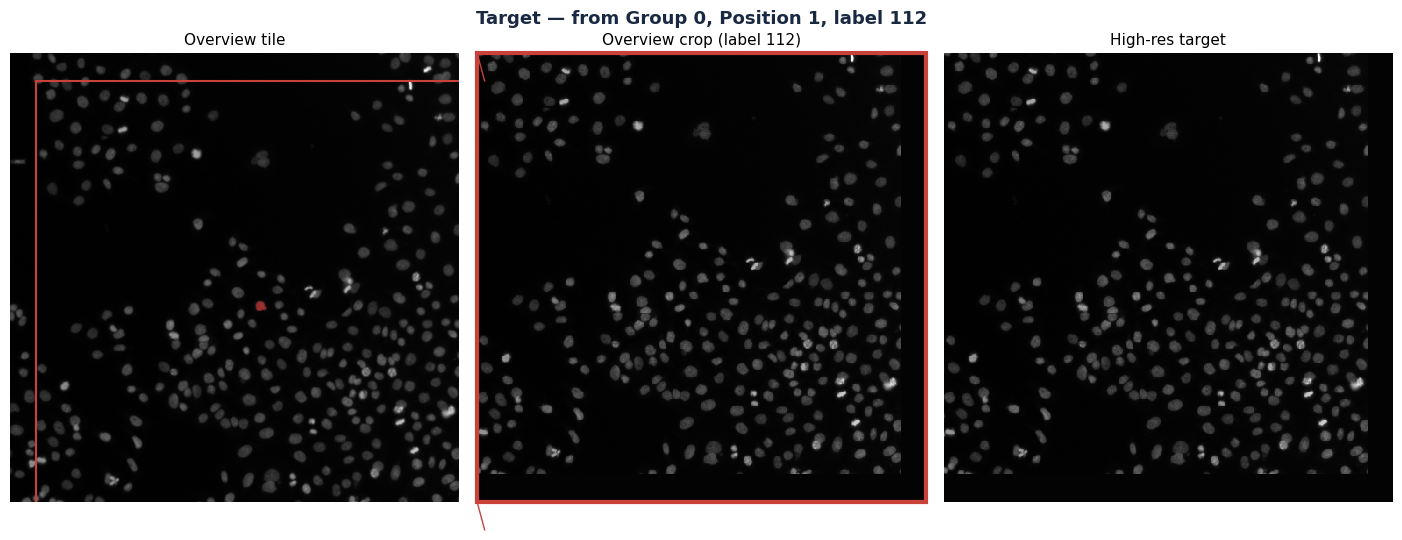


[step 5] Done: 8/8 targets acquired


In [9]:
from workflow import acquire_targets

records = acquire_targets(
    ctx, picks,
    live_display=cfg.visualize,
    save_png=cfg.visualize,
)

## Step 6 — Finish

Writes `run_summary.json`, plots the results, and shuts down the engine.

The Cleanup cell below is a safety backstop for interrupted runs — not part of the normal path.

In [ ]:
from workflow import write_summary, plot_results, finish
from workflow.selection import load_overview_result

# Reload from disk so the finish cell is consistent with selection above
# (restart-between-selection-and-finish is NOT supported -- picks,
# selection, and records must still be in-kernel here).
overview = load_overview_result(ctx.run.layout.analysis_dir("overview-scan"))
write_summary(ctx, focus_map, overview, picks, selection, records)
plot_results(ctx, focus_map, picks, records)
finish(ctx)

In [ ]:
# Cleanup -- safety backstop for interrupted runs. Shuts down the
# analysis engine. Does NOT disconnect the LAS X client; it persists
# until kernel restart. Always safe to run.
try:
    ctx.shutdown()
except NameError:
    pass
